# 02 — Exploratory Data Analysis and Feature Engineering

This notebook explores failure prevalence, product-type differences, operating conditions associated with failure, nonlinear relationships among sensor variables, and two physically motivated engineered features used in the modeling stage.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

UCI_DATA_URL = "https://archive.ics.uci.edu/static/public/601/ai4i%2B2020%2Bpredictive%2Bmaintenance%2Bdataset.zip"

# Resolve the repository root when running locally. In a fresh Colab runtime,
# no repository data folder exists, so the notebook falls back to UCI.
def find_repo_root():
    cwd = Path.cwd()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return cwd

REPO_ROOT = find_repo_root()
LOCAL_DATA_PATH = REPO_ROOT / "data" / "raw" / "ai4i2020.csv"

if LOCAL_DATA_PATH.exists():
    df = pd.read_csv(LOCAL_DATA_PATH)
else:
    df = pd.read_csv(UCI_DATA_URL, compression="zip")


In [2]:
# Creates subfolders figures and tables in the colab environment where individual
# figures and tables are stored during the notebook run. Provides the user with
# the ability to download these and maintains reproducibility of the outputs

TABLES_DIR = Path("/content/outputs/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = Path("/content/outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = df.rename(columns={
    "UDI": "udi",
    "Product ID": "product_id",
    "Type": "type",
    "Air temperature [K]": "air_temperature_k",
    "Process temperature [K]": "process_temperature_k",
    "Rotational speed [rpm]": "rotational_speed_rpm",
    "Torque [Nm]": "torque_nm",
    "Tool wear [min]": "tool_wear_min",
    "Machine failure": "machine_failure",
    "TWF": "twf",
    "HDF": "hdf",
    "PWF": "pwf",
    "OSF": "osf",
    "RNF": "rnf"
})

In [4]:
df.columns.tolist()

['udi',
 'product_id',
 'type',
 'air_temperature_k',
 'process_temperature_k',
 'rotational_speed_rpm',
 'torque_nm',
 'tool_wear_min',
 'machine_failure',
 'twf',
 'hdf',
 'pwf',
 'osf',
 'rnf']

In [5]:
df.head()

,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
identifier_cols = ["udi", "product_id"]

In [7]:
failure_mode_cols = ["twf", "hdf", "pwf", "osf", "rnf"]

### Failure-mode indicators and target leakage

The five failure-mode columns (`twf`, `hdf`, `pwf`, `osf`, and `rnf`) describe specific failure outcomes. They are retained for exploratory analysis but excluded from the predictor set because using post-failure indicators to predict the aggregate `machine_failure` target would introduce target leakage.


In [8]:
target = "machine_failure"

excluded_cols = identifier_cols + failure_mode_cols

In [9]:
feature_cols = [
    "type",
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min"
    ]

### Modeling feature set

The binary model will use product type and pre-failure operating measurements to estimate machine-failure risk (`0 = no failure`, `1 = failure`). Identifier columns and failure-mode indicators are excluded from the predictors.


In [10]:
print("Dataset shape:", df.shape)
print("\nFeature columns:")
print(feature_cols)

print("\nTarget:")
print(target)

print("\nExcluded from modeling:")
print(excluded_cols)

print("\nMissing values in model variables:")
print(df[feature_cols + [target]].isna().sum())

Dataset shape: (10000, 14)

Feature columns:
['type', 'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']

Target:
machine_failure

Excluded from modeling:
['udi', 'product_id', 'twf', 'hdf', 'pwf', 'osf', 'rnf']

Missing values in model variables:
type                     0
air_temperature_k        0
process_temperature_k    0
rotational_speed_rpm     0
torque_nm                0
tool_wear_min            0
machine_failure          0
dtype: int64


In [11]:
df["type"].value_counts()

,count
type,
L,6000
M,2997
H,1003


### Product quality variant

The `type` feature represents the product quality variant rather than an equipment category. In this dataset, approximately 60% of observations are Type L, 30% Type M, and 10% Type H. Because product quality may be associated with failure risk, `type` is retained as a categorical predictor and will be encoded during modeling.


## 1. Failure Prevalence


In [12]:
failure_counts = df["machine_failure"].value_counts().sort_index()
failure_pct = (
    df["machine_failure"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

failure_summary = pd.DataFrame({
    "count": failure_counts,
    "percentage": failure_pct
})

failure_summary

,count,percentage
machine_failure,,
0,9661,96.61
1,339,3.39


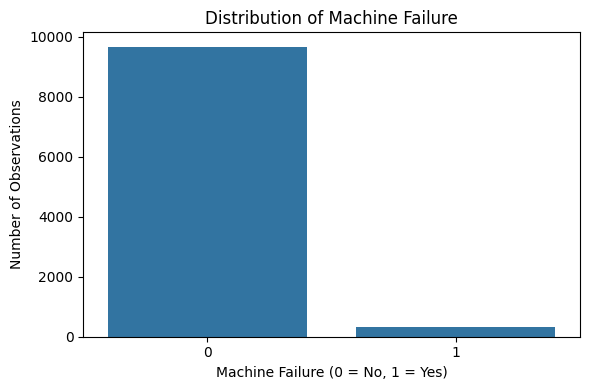

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="machine_failure"
)

plt.title("Distribution of Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Number of Observations")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Machine failures represent only 3.39% of observations, indicating substantial class imbalance. Accuracy alone would therefore be misleading: a classifier predicting no failure for every observation would already achieve 96.61% accuracy while detecting none of the failures.


## 2. Failure Rate by Product Type


In [14]:
type_failure = (
    df.groupby("type")["machine_failure"]
    .agg(["count", "sum", "mean"])
)

type_failure.columns = [
    "observations",
    "failures",
    "failure_rate"
]

type_failure["failure_rate_pct"] = (
    type_failure["failure_rate"] * 100
).round(2)

type_failure

,observations,failures,failure_rate,failure_rate_pct
type,,,,
H,1003,21,0.020937,2.09
L,6000,235,0.039167,3.92
M,2997,83,0.027694,2.77


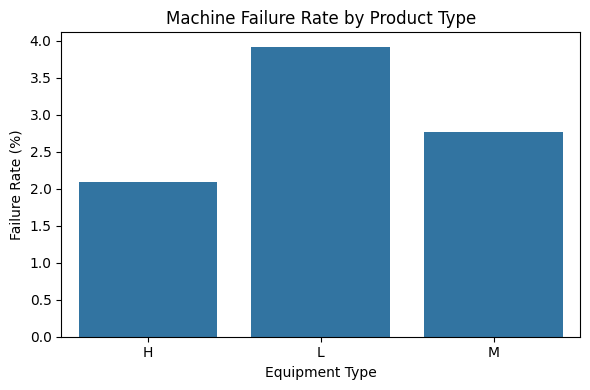

In [15]:
failure_rate_by_type = (
    df.groupby("type")["machine_failure"]
    .mean()
    .mul(100)
    .reset_index(name="failure_rate_pct")
)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=failure_rate_by_type,
    x="type",
    y="failure_rate_pct"
)

plt.title("Machine Failure Rate by Product Type")
plt.xlabel("Equipment Type")
plt.ylabel("Failure Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "failure_rate_by_product_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The observed failure rate differs across product types. Type L has the highest failure rate at approximately 3.9%, followed by Type M at 2.8% and Type H at 2.1%. Although the absolute differences are modest, they are meaningful relative to the overall failure rate of 3.39%; the observed failure rate for Type L is almost twice that of Type H.

This supports retaining product type as a candidate predictor, but the descriptive relationship does not establish causality. Product types may also differ in torque, tool wear, temperature, or other operating conditions, which the model will consider jointly.


## 3. Operating Conditions and Machine Failure

The next analysis asks whether failed observations operate under measurably different conditions from non-failed observations across the five original numerical predictors.


In [16]:
numeric_features = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min"
]

In [17]:
# Compare average operating conditions for failed and non-failed observations

failure_comparison = (df.groupby("machine_failure")[numeric_features].mean().T)

failure_comparison.columns = ["No Failure", "Failure"]

failure_comparison

,No Failure,Failure
air_temperature_k,299.973999,300.886431
process_temperature_k,309.995570,310.290265
rotational_speed_rpm,1540.260014,1496.486726
torque_nm,39.629655,50.168142
tool_wear_min,106.693717,143.781711


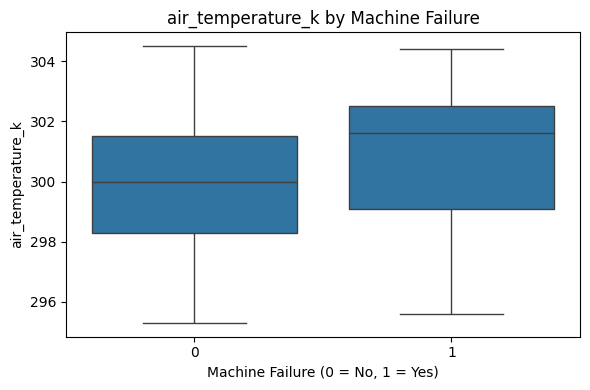

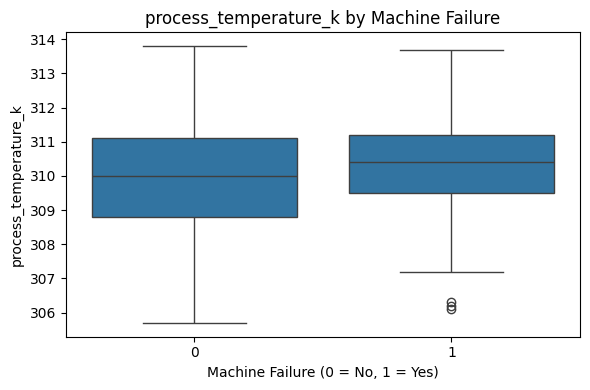

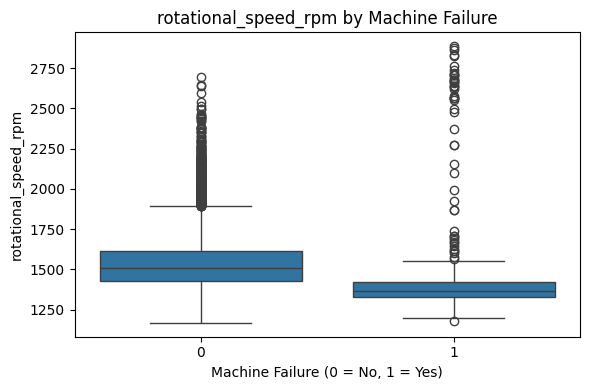

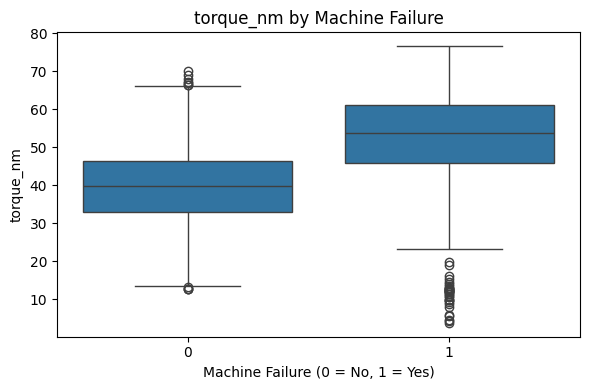

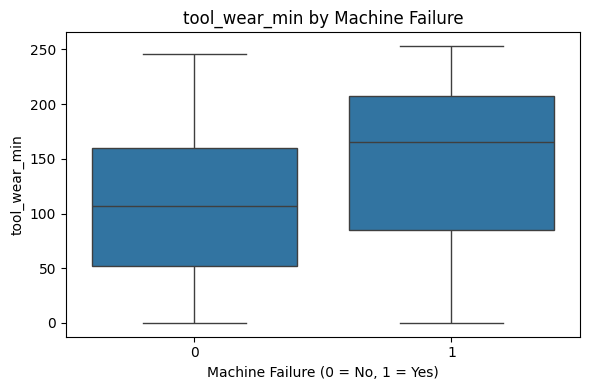

In [18]:
for feature in numeric_features:
  plt.figure(figsize = (6,4))

  sns.boxplot(data=df, x="machine_failure", y = feature)

  plt.title(f"{feature} by Machine Failure")
  plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
  plt.ylabel(feature)

  plt.tight_layout()

  plt.savefig(
    FIGURES_DIR / f"{feature}_by_machine_failure.png",
    dpi=300,
    bbox_inches="tight"
  )

  plt.show()



Failed observations are associated with higher average torque and substantially higher tool wear. Air temperature, process temperature, and tool wear show considerable overlap between classes, while torque and rotational speed exhibit clearer shifts in their central distributions.

Rotational speed is generally lower among failures, but a group of failures also occurs at very high RPM. Torque shows a similar nonlinear pattern: failures are common at high torque, while some failures also occur at very low torque. These patterns suggest that the relationship between operating conditions and failure is not purely linear, supporting the use of a model such as Random Forest that can capture nonlinear effects and interactions.


### Engineered Feature: Temperature Difference

The first engineered feature is the difference between process temperature and air temperature. It measures how much hotter the process is than the surrounding air and may capture thermal conditions more directly than either raw temperature alone.


In [19]:
df["temperature_difference_k"] = (df["process_temperature_k"] - df["air_temperature_k"])

df.groupby("machine_failure")["temperature_difference_k"].agg(["mean", "median", "std"])

,mean,median,std
machine_failure,,,
0,10.021571,9.8,0.988422
1,9.403835,9.3,1.164445


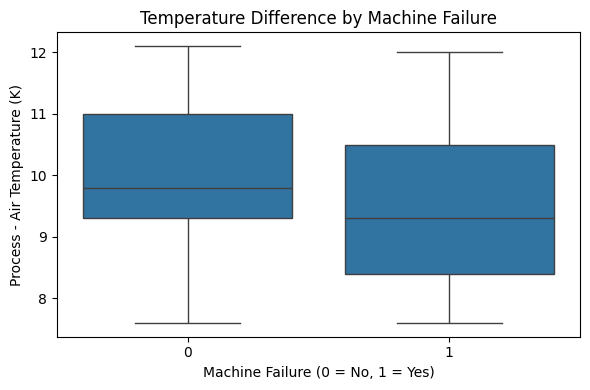

In [20]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="machine_failure",
    y="temperature_difference_k"
)

plt.title("Temperature Difference by Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Process - Air Temperature (K)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "temperature_difference_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The engineered temperature-difference feature also produces an interesting result: failure observations are associated with a smaller process-to-air temperature difference. This distinction is more noticeable than when process and air temperatures are considered independently, suggesting that the relationship between the two temperatures may contain useful predictive information.

## 4. Relationships Between Operating Variables


In [21]:
numeric_features_extended = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "temperature_difference_k"
]

In [22]:
corr_matrix = df[numeric_features_extended + ["machine_failure"]].corr()

corr_matrix.round(2)

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,temperature_difference_k,machine_failure
air_temperature_k,1.00,0.88,0.02,-0.01,0.01,-0.70,0.08
process_temperature_k,0.88,1.00,0.02,-0.01,0.01,-0.27,0.04
rotational_speed_rpm,0.02,0.02,1.00,-0.88,0.00,-0.02,-0.04
torque_nm,-0.01,-0.01,-0.88,1.00,-0.00,0.01,0.19
tool_wear_min,0.01,0.01,0.00,-0.00,1.00,-0.01,0.11
temperature_difference_k,-0.70,-0.27,-0.02,0.01,-0.01,1.00,-0.11
machine_failure,0.08,0.04,-0.04,0.19,0.11,-0.11,1.00


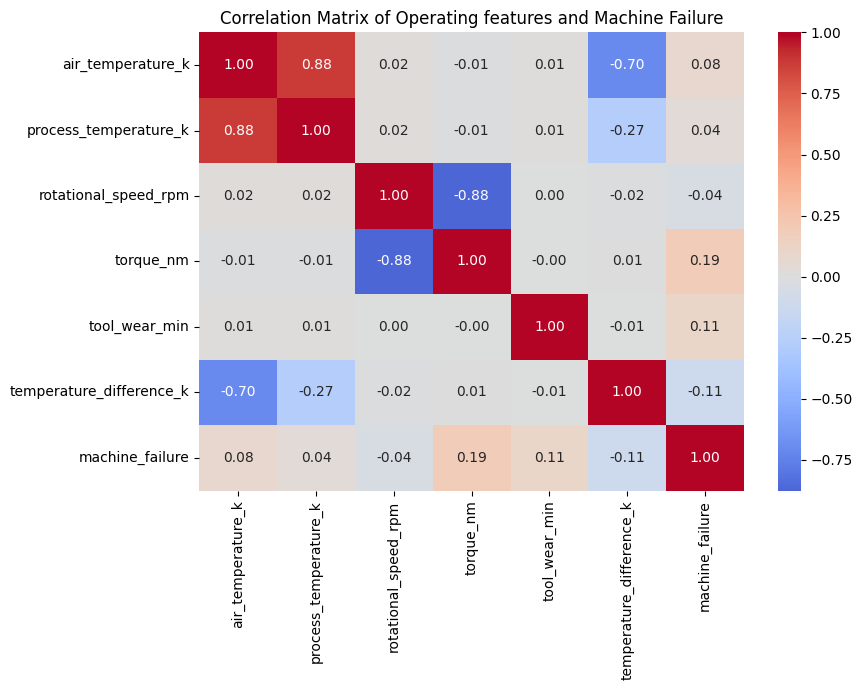

In [23]:
plt.figure(figsize = (9, 7))

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap ="coolwarm",
    center = 0
)

plt.title("Correlation Matrix of Operating features and Machine Failure")
plt.tight_layout()

plt.show()

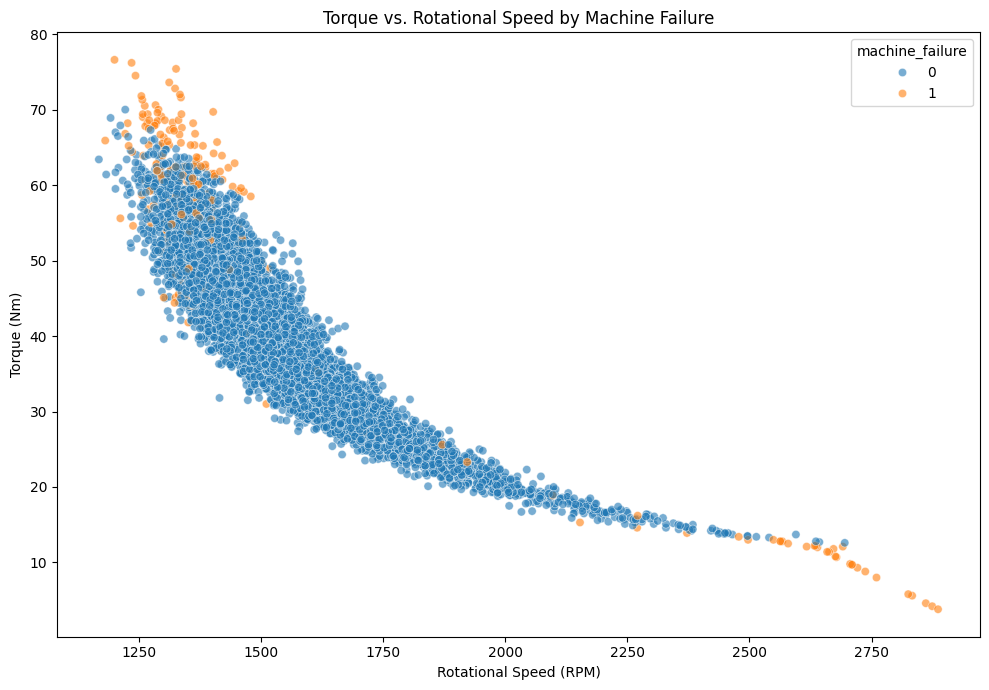

In [24]:
plt.figure(figsize = (10, 7))

sns.scatterplot(
    data = df,
    x = "rotational_speed_rpm",
    y = "torque_nm",
    hue = "machine_failure",
    alpha = 0.6
)

plt.title("Torque vs. Rotational Speed by Machine Failure")
plt.xlabel("Rotational Speed (RPM)")
plt.ylabel("Torque (Nm)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "torque_vs_rpm_by_machine_failure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Failures concentrate in particular regions of the torque–RPM operating space: especially higher torque with lower RPM, as well as a smaller high-RPM/low-torque region. This makes the nonlinear behavior seen in the univariate plots more explicit, so the next step quantifies failure rates across torque and RPM ranges.


In [25]:
df["torque_bin"] = pd.qcut(
    df["torque_nm"],
    q=5,
    duplicates="drop"
)

torque_failure_rate = (
    df.groupby("torque_bin", observed=True)["machine_failure"]
    .agg(["count", "sum", "mean"])
)

torque_failure_rate.columns = [
    "observations",
    "failures",
    "failure_rate"
]

torque_failure_rate["failure_rate_pct"] = (
    torque_failure_rate["failure_rate"] * 100
).round(2)

torque_failure_rate

,observations,failures,failure_rate,failure_rate_pct
torque_bin,,,,
"(3.799, 31.4]",2002,47,0.023477,2.35
"(31.4, 37.5]",2012,9,0.004473,0.45
"(37.5, 42.7]",2018,12,0.005946,0.59
"(42.7, 48.3]",1985,43,0.021662,2.17
"(48.3, 76.6]",1983,228,0.114977,11.50


In [26]:
df["rpm_bin"] = pd.qcut(
    df["rotational_speed_rpm"],
    q=5,
    duplicates="drop"
)

rpm_failure_rate = (
    df.groupby("rpm_bin", observed=True)["machine_failure"]
    .agg(["count", "sum", "mean"])
)

rpm_failure_rate.columns = [
    "observations",
    "failures",
    "failure_rate"
]

rpm_failure_rate["failure_rate_pct"] = (
    rpm_failure_rate["failure_rate"] * 100
).round(2)

rpm_failure_rate

,observations,failures,failure_rate,failure_rate_pct
rpm_bin,,,,
"(1167.999, 1405.0]",2007,244,0.121574,12.16
"(1405.0, 1470.0]",2011,29,0.014421,1.44
"(1470.0, 1541.0]",1999,12,0.006003,0.60
"(1541.0, 1644.0]",1992,9,0.004518,0.45
"(1644.0, 2886.0]",1991,45,0.022602,2.26


The correlation matrix shows a strong negative relationship between rotational speed and torque (-0.88), while air and process temperature are strongly positively correlated (0.88). When looking at their individual linear relationships with machine failure, torque shows the strongest correlation (0.19), while rotational speed has a very weak correlation (-0.04).

However, examining failure rates across operating ranges reveals information that linear correlation does not capture. The lowest rotational-speed quintile has a failure rate of 12.16%, compared with only 0.45–1.44% across much of the middle RPM range. Failure rate rises again to 2.26% in the highest RPM quintile. Therefore, the relationship between rotational speed and failure appears nonlinear despite its weak overall linear correlation with the target.

Torque shows a similar pattern. The highest-torque quintile has an 11.50% failure rate, while the middle torque ranges have failure rates below 1%. The lowest-torque range also shows an elevated failure rate of 2.35%, supporting the observation that failures may be associated with particular operating regimes rather than a simple linear increase or decrease in a single variable.

The torque-RPM scatterplot further shows the strong relationship between these two operating variables and concentrations of failures in extreme operating regions. These findings support testing a model such as Random Forest that can capture nonlinear relationships and interactions between features.

## 5. Feature Engineering: Mechanical Power

In addition to the original predictors and temperature difference, a second physically meaningful feature is created from torque and rotational speed. Angular velocity is

$\omega = 2\pi \times \mathrm{RPM} / 60$

and rotational mechanical power is

$P = \tau \omega$,

where $\tau$ is torque. The resulting feature is expressed in kilowatts.


In [27]:
# Mechanical rotational power: P = torque × angular velocity
df["mechanical_power_kw"] = (
    df["torque_nm"]
    * df["rotational_speed_rpm"]
    * 2
    * np.pi
    / 60
    / 1000
)


In [28]:
df["mechanical_power_kw"].describe()

,mechanical_power_kw
count,10000.000000
mean,6.279745
std,1.067418
min,1.148441
25%,5.561184
50%,6.271027
75%,7.003003
max,10.469923


In [29]:
df.groupby("machine_failure")["mechanical_power_kw"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
machine_failure,,,
0,6.244548,6.243046,1.011394
1,7.282819,7.611430,1.851138


In [30]:
df.groupby("machine_failure")[
    ["temperature_difference_k", "mechanical_power_kw"]
].mean()

,temperature_difference_k,mechanical_power_kw
machine_failure,,
0,10.021571,6.244548
1,9.403835,7.282819


The engineered mechanical-power feature differs noticeably between failure and non-failure observations. Failed observations have higher mean power (7.28 kW vs. 6.24 kW), higher median power (7.61 kW vs. 6.24 kW), and greater variability (standard deviation 1.85 kW vs. 1.01 kW).

Because mechanical power combines torque and rotational speed into a physically meaningful measure of operating state, it is retained as a candidate model feature. Its predictive contribution will be interpreted cautiously because it is derived directly from variables already present in the feature set.


## 6. Final Modeling Feature Set

The modeling dataset retains the original operating variables, product type, and the two engineered features: temperature difference and mechanical power.


In [31]:
numeric_features_model = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "temperature_difference_k",
    "mechanical_power_kw"
]

categorical_features_model = [
    "type"
]

In [32]:
X = df[
    numeric_features_model
    + categorical_features_model
].copy()

y = df["machine_failure"].copy()

In [33]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (10000, 8)
y shape: (10000,)


,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,temperature_difference_k,mechanical_power_kw,type
0,298.1,308.6,1551,42.8,0,10.5,6.951591,M
1,298.2,308.7,1408,46.3,3,10.5,6.826723,L
2,298.1,308.5,1498,49.4,5,10.4,7.749388,L
3,298.2,308.6,1433,39.5,7,10.4,5.927505,L
4,298.2,308.7,1408,40.0,9,10.5,5.897817,L


In [34]:
print("Model features:")
for feature in X.columns:
    print(f"- {feature}")

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values:")
print(X.isna().sum())

print("\nDataset dimensions:")
print(X.shape, y.shape)

Model features:
- air_temperature_k
- process_temperature_k
- rotational_speed_rpm
- torque_nm
- tool_wear_min
- temperature_difference_k
- mechanical_power_kw
- type

Target distribution:
machine_failure
0    9661
1     339
Name: count, dtype: int64

Missing values:
air_temperature_k           0
process_temperature_k       0
rotational_speed_rpm        0
torque_nm                   0
tool_wear_min               0
temperature_difference_k    0
mechanical_power_kw         0
type                        0
dtype: int64

Dataset dimensions:
(10000, 8) (10000,)


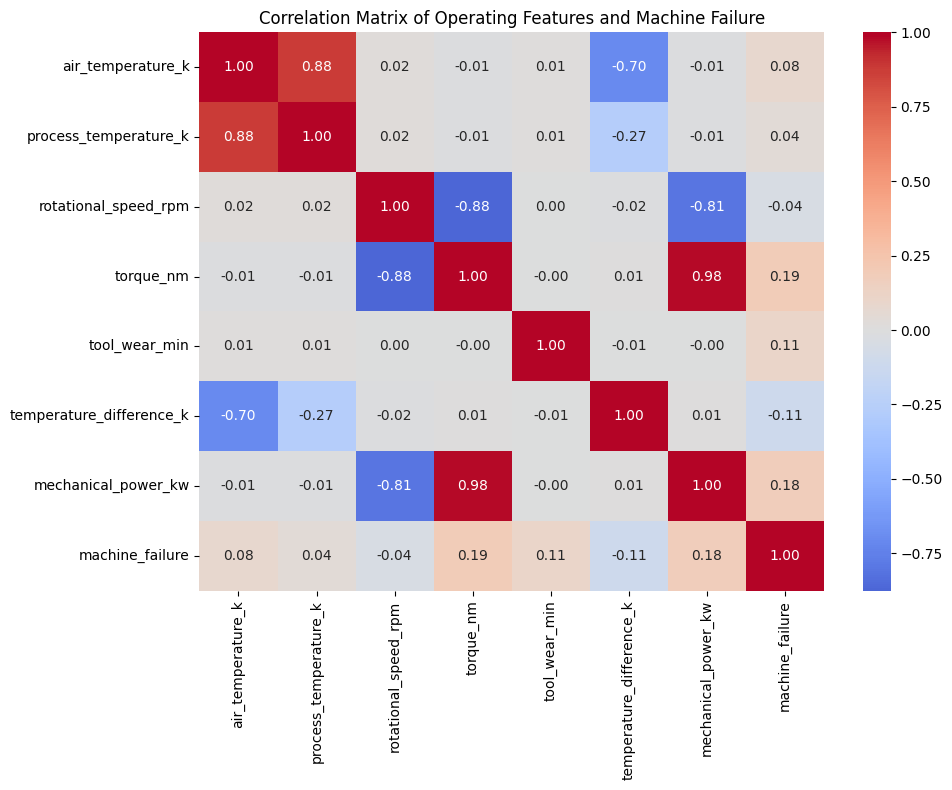

In [35]:
numeric_features_extended = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "temperature_difference_k",
    "mechanical_power_kw"
]

corr_matrix = df[
    numeric_features_extended + ["machine_failure"]
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Operating Features and Machine Failure")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Mechanical power shows a positive correlation of 0.18 with machine failure, comparable to torque (0.19). However, mechanical power is also extremely strongly correlated with torque (0.98) and negatively correlated with rotational speed (-0.81), which is expected because it is derived directly from these variables. It will be retained as a candidate engineered feature, but its contribution should be interpreted cautiously because it contains information already represented by torque and rotational speed.